In [1]:
import pandas as pd
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
mod_a0 = r"D:\methane\mod\clean\run_bg_A000_W1416.csv"
mod_a10 = r"D:\methane\mod\clean\run_bg_A100_W1416.csv"
hisui = r"D:\methane\spectral_data_sample_HSHL1G_N345E1354_20201027020705_20221013062213_x840_y1175.csv"
band = r"D:\methane\HSHL1G_N402E0583_20210803092156_20240106123056_B.csv"

bandinfo = pd.read_csv(band)
hisui_spec = pd.read_csv(hisui)
mod_a0 = pd.read_csv(mod_a0)
mod_a10 = pd.read_csv(mod_a10)
print(hisui_spec)

bandinfo_cols = bandinfo.columns.tolist()
hisui_cols = hisui_spec.columns.tolist()
mod_cols = mod_a0.columns.tolist()
print(bandinfo_cols, hisui_cols, mod_cols)

    Wavelength  Radiance
0     1800.295    4.0672
1     1812.785    1.0624
2     1825.275    0.5248
3     1837.765    0.4672
4     1850.255    0.4256
5     1862.745    0.3680
6     1875.235    0.3872
7     1887.725    0.3328
8     1900.215    0.3520
9     1912.705    0.3328
10    1925.195    0.3744
11    1937.685    0.4896
12    1950.175    0.8320
13    1962.665    2.1056
14    1975.155    5.9456
15    1987.645    8.6336
16    2000.135    5.0944
17    2012.625    2.7296
18    2025.115    6.8896
19    2037.605   11.6352
20    2050.095    9.8368
21    2062.585    8.0896
22    2075.075    9.9808
23    2087.565   12.5600
24    2100.055   13.3408
25    2112.545   13.6256
26    2125.035   13.6192
27    2137.525   13.9552
28    2150.015   13.1648
29    2162.505   12.2336
30    2174.995   11.9360
31    2187.485   11.3056
32    2199.975   10.6176
33    2212.465   10.8768
34    2224.955   10.9632
35    2237.445   10.5792
36    2249.935    9.9200
37    2262.425    9.2960
38    2274.915    8.9568


In [3]:
mod_a0_conv = mod_a0.copy()
mod_a10_conv = mod_a10.copy()
mod_a0_conv["radiance_wm2_sru_um"] = mod_a0_conv["radiance"] * 10
mod_a10_conv["radiance_wm2_sru_um"] = mod_a10_conv["radiance"] * 10 #単位
print(mod_a0_conv)
print(mod_a10_conv)

target_anchor_nm = 2139.0 #アルベド推定に2139nmを使用
bandinfo["abs_diff_anchor"] = (bandinfo["CenterWavelengthNanometer"] - target_anchor_nm).abs() #2139との差(絶対値)
anchor_row = bandinfo.loc[bandinfo["abs_diff_anchor"].idxmin()] #差が一番小さい列を取り出す
anchor_bandno = int(anchor_row["BandNo"])
anchor_center = float(anchor_row["CenterWavelengthNanometer"])
anchor_fwhm = float(anchor_row["FullWidthAtHalfMaximumNanometer"])
print(anchor_bandno, anchor_center, anchor_fwhm)

      wave_nm  radiance  radiance_wm2_sru_um
0      2100.0  0.004767             0.047671
1      2100.2  0.004740             0.047395
2      2100.4  0.004731             0.047308
3      2100.6  0.004740             0.047400
4      2100.8  0.004741             0.047413
...       ...       ...                  ...
1496   2399.2  0.002430             0.024304
1497   2399.4  0.002400             0.024002
1498   2399.6  0.002339             0.023394
1499   2399.8  0.002242             0.022420
1500   2400.0  0.002124             0.021236

[1501 rows x 3 columns]
      wave_nm  radiance  radiance_wm2_sru_um
0      2100.0  0.228769             2.287690
1      2100.2  0.226438             2.264380
2      2100.4  0.225699             2.256990
3      2100.6  0.226556             2.265560
4      2100.8  0.226871             2.268710
...       ...       ...                  ...
1496   2399.2  0.117913             1.179130
1497   2399.4  0.116040             1.160400
1498   2399.6  0.111550       

In [4]:
ch4_min, ch4_max = 2248.0, 2298.0 #論文より(あっちは6本になったため、6本に調整すべきか？)
ch4_bands = bandinfo[(bandinfo["CenterWavelengthNanometer"] >= ch4_min) & 
                     (bandinfo["CenterWavelengthNanometer"] <= ch4_max)].copy()
ch4_bands = ch4_bands.sort_values("CenterWavelengthNanometer")
ch4_bands[["BandNo", "CenterWavelengthNanometer", "FullWidthAtHalfMaximumNanometer"]],len(ch4_bands)

(     BandNo  CenterWavelengthNanometer  FullWidthAtHalfMaximumNanometer
 166     167                   2249.935                          13.1822
 167     168                   2262.425                          13.1808
 168     169                   2274.915                          13.1793
 169     170                   2287.405                          13.1779,
 4)

In [5]:
def gaussian_weights(wave_nm, center_nm, fwhm_nm):
    sigma = fwhm_nm / (2 * math.sqrt(2 * math.log(2)))  #FWHM -> sigma,半値点からx=μ±σ√2ln2これの差がFWHM
    w = np.exp(-0.5 * ((wave_nm - center_nm) / sigma) ** 2)
    w_sum = w.sum()
    if w_sum == 0:
        return w
    return w / w_sum

def convolve_band(wave_nm, rad, center_nm, fwhm_nm): #高分解能スペクトルrad(λ)を、そのバンドのRSR重みw(λ)で加重平均→そのバンドが実際に観測する放射輝度
    w = gaussian_weights(wave_nm, center_nm, fwhm_nm)
    return float(np.sum(rad * w))

In [6]:
wave_nm = mod_a0_conv["wave_nm"].values
rad_a0 = mod_a0_conv["radiance_wm2_sru_um"].values
rad_a10 = mod_a10_conv["radiance_wm2_sru_um"].values

L_path = convolve_band(wave_nm, rad_a0, anchor_center, anchor_fwhm) #反射0%でセンサが観測する明るさ
L10_anchor = convolve_band(wave_nm, rad_a10, anchor_center, anchor_fwhm)
print(wave_nm, rad_a0, rad_a10, L_path, L10_anchor)

[2100.  2100.2 2100.4 ... 2399.6 2399.8 2400. ] [0.0476705 0.0473954 0.0473081 ... 0.0233941 0.0224198 0.0212359] [2.28769  2.26438  2.25699  ... 1.1155   1.04107  0.950258] 0.04569194314056108 2.3307318735759464


In [7]:
hisui_waves = hisui_spec["Wavelength"].values
hisui_rads = hisui_spec["Radiance"].values
idx_anchor_obs = int(np.argmin(np.abs(hisui_waves - anchor_center))) #ac=2137.525nm,各波長とこれが一番近いidx
lambda_anchor_obs = float(hisui_waves[idx_anchor_obs]) #基準に最も近い観測波長
L_av_anchor = float(hisui_rads[idx_anchor_obs]) #この時の放射輝度
print(idx_anchor_obs,lambda_anchor_obs,L_av_anchor)

A = (L_av_anchor - L_path) / (L10_anchor - L_path) * 0.10 #論文の式(1)
print(A)

27 2137.525 13.9552
0.6087205685814496


In [8]:
rows = []
chi = 0.10 / A #χ = A(LUTb)/A(estimated) 式(2)の下
for i, r in ch4_bands.iterrows():
    bandno = int(r["BandNo"])
    center = float(r["CenterWavelengthNanometer"])
    fwhm = float(r["FullWidthAtHalfMaximumNanometer"])
    Lb = convolve_band(wave_nm, rad_a10, center, fwhm)  #10%での観測する輝度
    idx_obs = int(np.argmin(np.abs(hisui_waves - center)))
    L_av = float(hisui_rads[idx_obs])
    lambda_obs = float(hisui_waves[idx_obs])
    
    L_res = Lb - chi * L_av
    
    rows.append({
        "BandNo": bandno,
        "Center_nm": center,
        "FWHM_nm": fwhm,
        "L_b": Lb,
        "L_av": L_av,
        "chi": chi,
        "L_res": L_res,
        "Residual(L_b - chi*L_av)": Lb - chi * L_av
    })
res_df = pd.DataFrame(rows)
print(res_df)

   BandNo  Center_nm  FWHM_nm       L_b    L_av       chi     L_res  \
0     167   2249.935  13.1822  1.773813  9.9200  0.164279  0.144165   
1     168   2262.425  13.1808  1.673028  9.2960  0.164279  0.145891   
2     169   2274.915  13.1793  1.628402  8.9568  0.164279  0.156988   
3     170   2287.405  13.1779  1.549551  8.3264  0.164279  0.181698   

   Residual(L_b - chi*L_av)  
0                  0.144165  
1                  0.145891  
2                  0.156988  
3                  0.181698  


In [9]:
N = len(res_df)
sum_res = float(res_df["Residual(L_b - chi*L_av)"].sum())
C_value = (sum_res / (N * A)) * 100 #論文と違い今はumで計算していたのでnm単位にするためスケーリングの係数は100
print(C_value)

25.82228075465145


In [19]:
cols = [
    "CenterWavelengthNanometer",
    "FullWidthAtHalfMaximumNanometer",
    "SolarIrradianceWatt/Meter2/Micron",
    "ReflectanceMulti",
    "ReflectanceAdd",
]

df_param = pd.DataFrame(param, columns=cols)  
print(df_param)

     CenterWavelengthNanometer  FullWidthAtHalfMaximumNanometer  \
0                      405.000                           9.9334   
1                      415.000                           9.9333   
2                      425.000                           9.9331   
3                      435.000                           9.9329   
4                      445.000                           9.9327   
..                         ...                              ...   
180                   2424.795                          13.1616   
181                   2437.285                          13.1601   
182                   2449.775                          13.1586   
183                   2462.265                          13.1570   
184                   2474.755                          13.1555   

     SolarIrradianceWatt/Meter2/Micron  ReflectanceMulti  ReflectanceAdd  
0                             1737.200          0.000019       -0.018620  
1                             1729.400       

In [12]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

In [11]:
import tifffile
import os

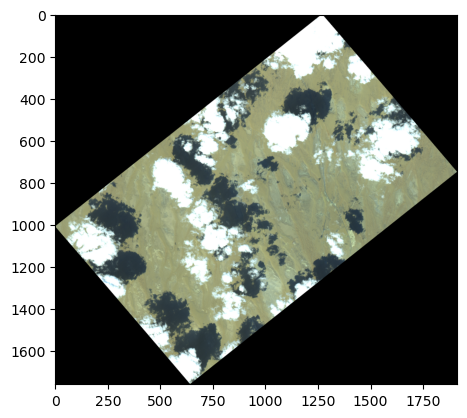

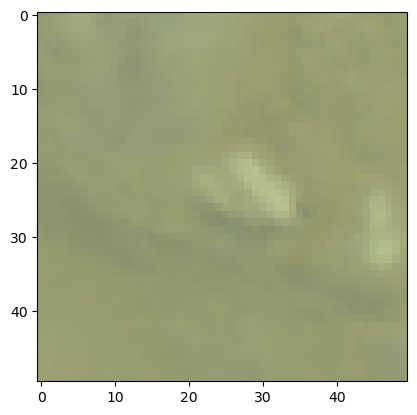

In [13]:
# ファイルの読み込み
file = r"C:\Users\yudon\OneDrive\デスクトップ\メタン\2025_HISUI_1_地獄の門\HSHL1G_N402E0583_20210803092156_20240106123056\HSHL1G_N402E0583_20210803092156_20240106123056.tif"
img = tifffile.imread(file) # read tif file
param = read_bfile(file)    # read radiometric file (..._B.csv)
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(file)  # read meta file (....txt)
img = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)  # apply radiometric parameter
ims = get_rgb(img, b=8, g=18, r=28)
center = np.array([1410, 700]) #中心座標(y, x), ここを変える
#ここで切り取りの範囲を設定
img_slice = img[center[0] - 100 : center[0] + 100, center[1] -100 : center[1] + 100, :] #補正後の画像
ims_slice = ims[center[0] - 25 : center[0] + 25, center[1] -25 : center[1] + 25, :] #画像表示用の画像
show_img(ims)
show_img(ims_slice)

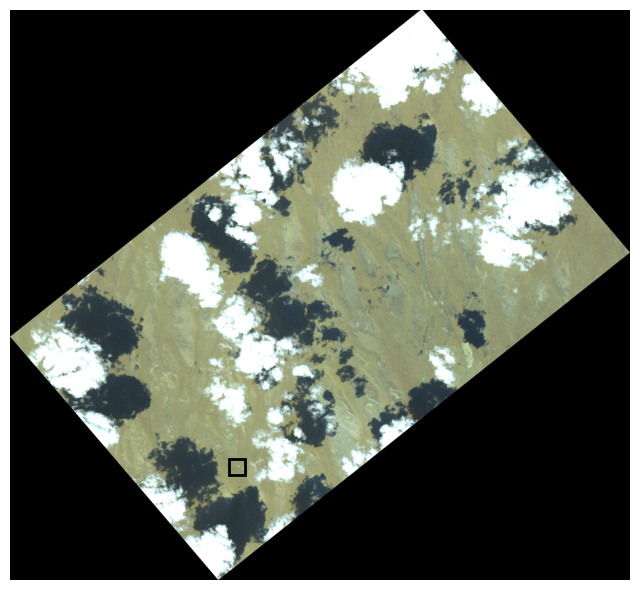

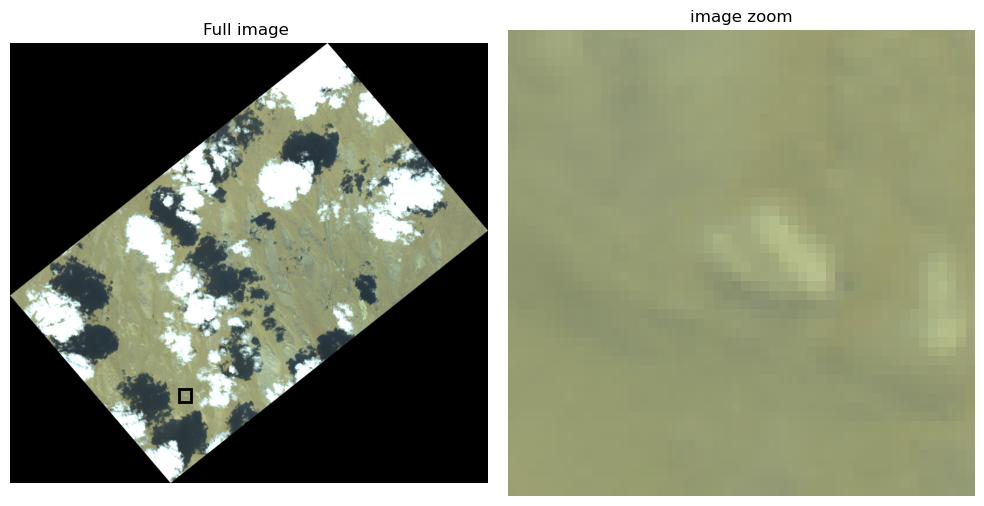

In [15]:
# ---- 切り出しサイズの設定（高さh, 幅w）----
# 例：縦・横どちらも 50 ピクセルで合わせる
h = 50  # 高さ（y方向）
w = 50  # 幅（x方向）
from matplotlib.patches import Rectangle
cy, cx = map(int, center)  # center = [y, x]
y1, y2 = cy - h//2, cy + h//2
x1, x2 = cx - w//2, cx + w//2

# 画像サイズに収まるようにクリップ（はみ出し対策）
H, W = ims.shape[:2]
y1, y2 = max(0, y1), min(H, y2)
x1, x2 = max(0, x1), min(W, x2)

# ---- 切り出し（表示用と処理用が同じ範囲になるよう統一）----
img_slice = img[y1:y2, x1:x2, :]
ims_slice = ims[y1:y2, x1:x2, :]

# ---- 枠を重ねて表示 ----
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(ims)
rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                 fill=False, linewidth=2)
ax.add_patch(rect)
ax.set_title("")
ax.set_axis_off()

# ---- ついでに右側にズーム（切り出し）も並べて表示 ----
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
ax2[0].imshow(ims)
ax2[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
ax2[0].set_title("Full image ")
ax2[0].set_axis_off()
ax2[1].imshow(ims_slice)
ax2[1].set_title("image zoom")
ax2[1].set_axis_off()
plt.tight_layout()
plt.show()


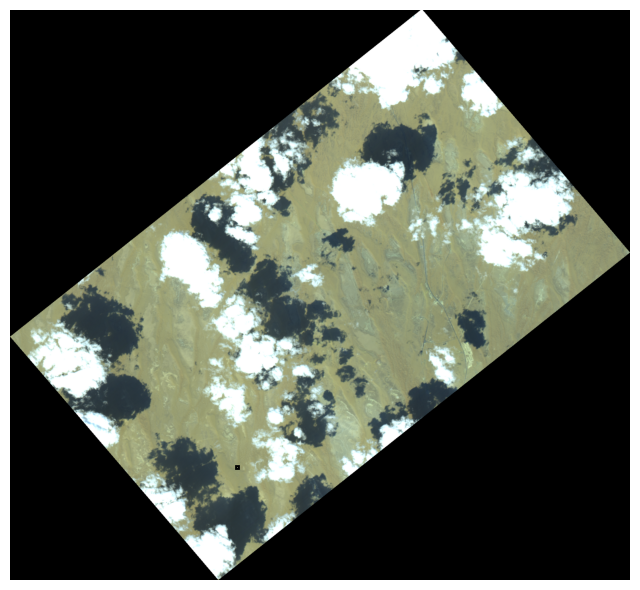

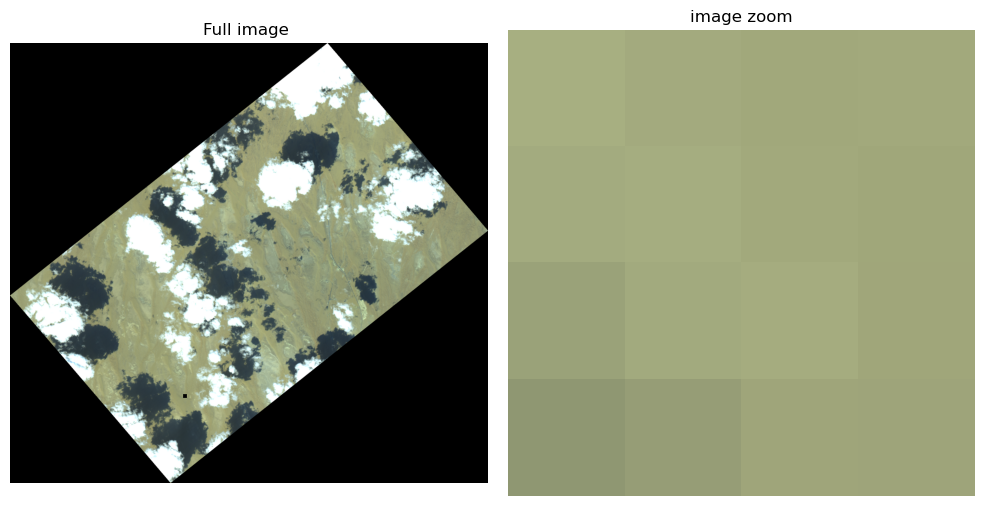

In [ ]:
from matplotlib.patches import Rectangle

# ---- 切り出しサイズの設定（高さh, 幅w）----
# 例：縦・横どちらも 50 ピクセルで合わせる
h = 4  # 高さ（y方向）
w = 4  # 幅（x方向）

cy, cx = map(int, center)  # center = [y, x]
y1, y2 = cy - h//2, cy + h//2
x1, x2 = cx - w//2, cx + w//2

# 画像サイズに収まるようにクリップ（はみ出し対策）
H, W = ims.shape[:2]
y1, y2 = max(0, y1), min(H, y2)
x1, x2 = max(0, x1), min(W, x2)

# ---- 切り出し（表示用と処理用が同じ範囲になるよう統一）----
img_slice = img[y1:y2, x1:x2, :]
ims_slice = ims[y1:y2, x1:x2, :]

# ---- 枠を重ねて表示 ----
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(ims)
rect = Rectangle((x1, y1), x2 - x1, y2 - y1,
                 fill=False, linewidth=2)
ax.add_patch(rect)
ax.set_title("")
ax.set_axis_off()

# ---- ついでに右側にズーム（切り出し）も並べて表示 ----
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
ax2[0].imshow(ims)
ax2[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))
ax2[0].set_title("Full image ")
ax2[0].set_axis_off()
ax2[1].imshow(ims_slice)
ax2[1].set_title("image zoom")
ax2[1].set_axis_off()
plt.tight_layout()
plt.show()

In [20]:
ch4_df = df_param[(df_param["CenterWavelengthNanometer"] >= 2248.0) &
               (df_param["CenterWavelengthNanometer"] <= 2298.0)].copy()
ch4_df = ch4_df.sort_values("CenterWavelengthNanometer")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


Text(0.5, 1.0, 'C (scaled W m^-2 sr^-1 nm^-1)')

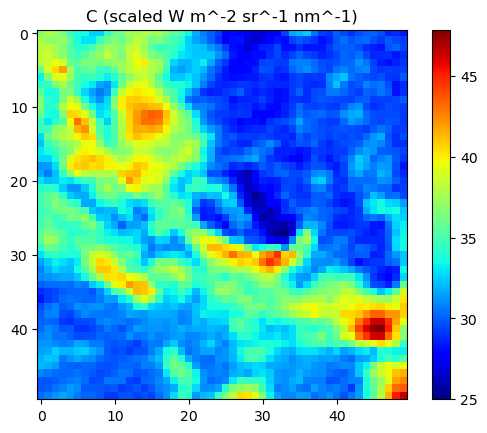

In [21]:
H, W, C = img_slice.shape
out_A  = np.full((H, W), np.nan, dtype=np.float32)
out_C  = np.full((H, W), np.nan, dtype=np.float32)
out_QA = np.zeros((H, W), dtype=np.uint8)
anchor_target = 2139
df_param = df_param.copy()
df_param["absdiff"] = (df_param["CenterWavelengthNanometer"] - anchor_target).abs()
anchor_row = df_param.loc[df_param["absdiff"].idxmin()]

ANCHOR_CENTER = float(anchor_row["CenterWavelengthNanometer"])
ANCHOR_FWHM   = float(anchor_row["FullWidthAtHalfMaximumNanometer"])

CH4_BANDS = ch4_df[["CenterWavelengthNanometer","FullWidthAtHalfMaximumNanometer"]].to_numpy()

Lb_list = []
for center_nm, fwhm_nm in CH4_BANDS:
    Lb_list.append(
        convolve_band(wave_nm, rad_a10, float(center_nm), float(fwhm_nm))
    )
Lb_list = np.array(Lb_list, dtype=float)
N_CH4 = len(CH4_BANDS)  

for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        pix_wave = df["Wavelength"].to_numpy(dtype=float)
        pix_rad  = df["Radiance"].to_numpy(dtype=float)  

        idx_anchor  = int(np.abs(pix_wave - ANCHOR_CENTER).argmin())
        Lav_anchor  = float(pix_rad[idx_anchor])

        denom = (L10_anchor - L_path)
        if not np.isfinite(Lav_anchor) or denom <= 0:
            out_QA[y, x] = 1
            continue
        A = (Lav_anchor - L_path) / denom * 0.10
        if not np.isfinite(A) or A <= 0:
            out_QA[y, x] = 1
            continue

        chi = 0.10 / A

        sum_res = 0.0
        for j, (center_nm, fwhm_nm) in enumerate(CH4_BANDS):
            idx  = int(np.abs(pix_wave - center_nm).argmin())
            Lav  = float(pix_rad[idx])
            Lb   = float(Lb_list[j])
            Lres = Lb - chi * Lav
            sum_res += Lres

        C_scaled = (sum_res / (N_CH4 * A)) * 100.0

        out_A[y, x] = A
        out_C[y, x] = C_scaled
plt.imshow(out_C, cmap="jet"); plt.colorbar(); plt.title("C (scaled W m^-2 sr^-1 nm^-1)")

Local coefficients: 8.055539113443395e-05 0.054823303736186685 1.798190180988429
CH4_local  (ppm)  min/med/mean/max: (np.float32(3.2190742), np.float32(3.6360555), np.float32(3.6963294), np.float32(4.607674))
CH4_roberts(ppm)  min/med/mean/max: (np.float32(5.5923605), np.float32(6.880866), np.float32(7.0740623), np.float32(9.994677))
Diff (local - roberts)  min/med/mean/max: (np.float32(-5.3870025), np.float32(-3.2448106), np.float32(-3.3777332), np.float32(-2.3732862))
MAE=3.3777 ppm, RMSE=3.4143 ppm, Bias=-3.3777 ppm


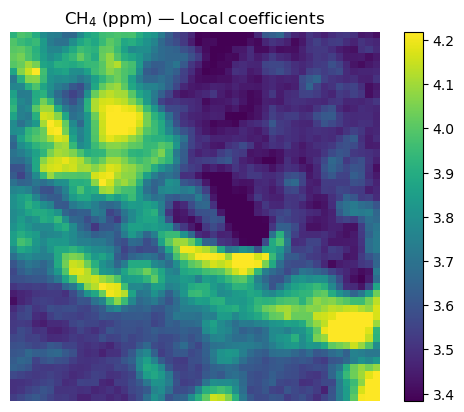

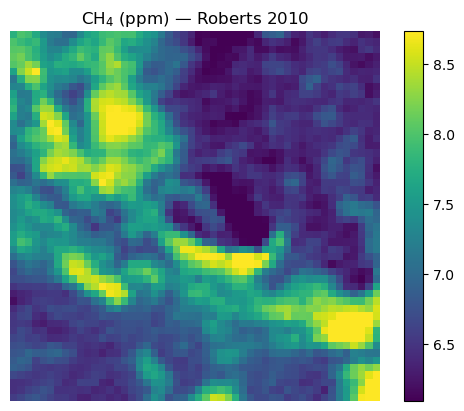

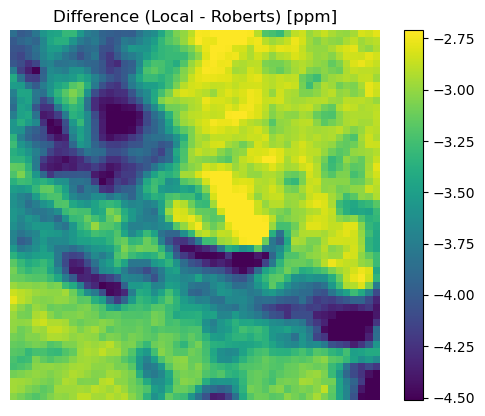

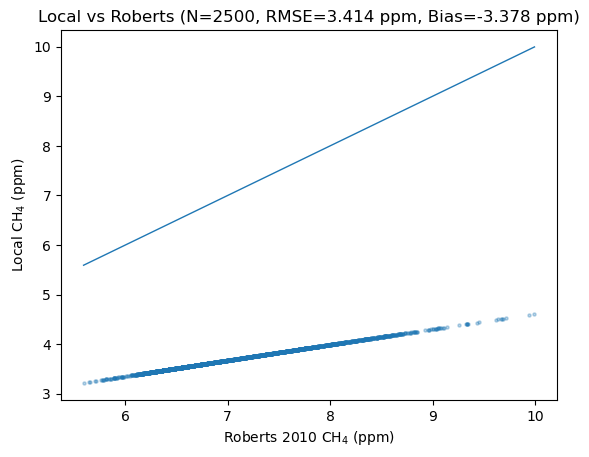

In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ==== 1) 係数を読み込み（あなたのJSONパスに合わせてください） ====
with open(r"D:\methanewide\ch4_from_c_coefficients.json", "r", encoding="utf-8") as f:
    cfg = json.load(f)

a_loc = cfg["quadratic_coefficients"]["a"]
b_loc = cfg["quadratic_coefficients"]["b"]
c_loc = cfg["quadratic_coefficients"]["c"]
print("Local coefficients:", a_loc, b_loc, c_loc)

# ==== 2) 変換関数（ローカル回帰 vs Roberts+2010）====
def c_to_ch4_local(C):
    # ローカル回帰（アップロードJSON）
    return a_loc * (C**2) + b_loc * C + c_loc

def c_to_ch4_roberts(C):
    # Roberts+2010 Fig.9（論文既知の近似）
    return 0.000556 * (C**2) + 0.1519 * C + 1.4475

# ==== 3) マスク（QAがあれば使う）====
valid = np.isfinite(out_C)
if "out_QA" in globals():
    valid &= (out_QA == 0)

# ==== 4) 2種類のメタン濃度（ppm）を計算 ====
CH4_local   = np.full_like(out_C, np.nan, dtype=np.float32)
CH4_roberts = np.full_like(out_C, np.nan, dtype=np.float32)

CH4_local[valid]   = c_to_ch4_local(out_C[valid])
CH4_roberts[valid] = c_to_ch4_roberts(out_C[valid])

# 差分（ローカル − Roberts）
CH4_diff = CH4_local - CH4_roberts

# ==== 5) 統計 ====
def nanstats(arr):
    return (np.nanmin(arr), np.nanpercentile(arr, 50), np.nanmean(arr), np.nanmax(arr))

print("CH4_local  (ppm)  min/med/mean/max:", nanstats(CH4_local))
print("CH4_roberts(ppm)  min/med/mean/max:", nanstats(CH4_roberts))
print("Diff (local - roberts)  min/med/mean/max:", nanstats(CH4_diff))

# 誤差指標（ローカル → 基準：Roberts）
mask = np.isfinite(CH4_local) & np.isfinite(CH4_roberts)
mae  = float(np.nanmean(np.abs(CH4_local[mask] - CH4_roberts[mask])))
rmse = float(np.sqrt(np.nanmean((CH4_local[mask] - CH4_roberts[mask])**2)))
bias = float(np.nanmean(CH4_local[mask] - CH4_roberts[mask]))
print(f"MAE={mae:.4f} ppm, RMSE={rmse:.4f} ppm, Bias={bias:.4f} ppm")

# ==== 6) 可視化（任意）====
# マップ
plt.figure(); 
plt.imshow(CH4_local, vmin=np.nanpercentile(CH4_local, 2), vmax=np.nanpercentile(CH4_local, 98))
plt.title("CH$_4$ (ppm) — Local coefficients"); plt.colorbar(); plt.axis("off"); plt.show()

plt.figure(); 
plt.imshow(CH4_roberts, vmin=np.nanpercentile(CH4_roberts, 2), vmax=np.nanpercentile(CH4_roberts, 98))
plt.title("CH$_4$ (ppm) — Roberts 2010"); plt.colorbar(); plt.axis("off"); plt.show()

plt.figure(); 
plt.imshow(CH4_diff, vmin=np.nanpercentile(CH4_diff, 2), vmax=np.nanpercentile(CH4_diff, 98))
plt.title("Difference (Local - Roberts) [ppm]"); plt.colorbar(); plt.axis("off"); plt.show()

# 散布図
plt.figure()
plt.scatter(CH4_roberts[mask], CH4_local[mask], s=5, alpha=0.3)
lims = [np.nanmin(CH4_roberts[mask]), np.nanmax(CH4_roberts[mask])]
plt.plot(lims, lims, lw=1)  # 1:1 line
plt.xlabel("Roberts 2010 CH$_4$ (ppm)"); plt.ylabel("Local CH$_4$ (ppm)")
plt.title(f"Local vs Roberts (N={mask.sum()}, RMSE={rmse:.3f} ppm, Bias={bias:.3f} ppm)")
plt.show()

# ==== 7) 保存（必要なら）====
np.save("CH4_ppm_local.npy",   CH4_local)
np.save("CH4_ppm_roberts.npy", CH4_roberts)
np.save("CH4_ppm_diff.npy",    CH4_diff)


In [23]:
# === 追加: bg_surref_由来のC値/CH4(ppm)を計算し、mod由来と比較 ===
import pandas as pd
import numpy as np

# 1) 入力パス（ユーザー指定）
surref_a0_path  = r"D:\methanewide\bgw\normalized\bg_surref_0.00_scan.csv"
surref_a10_path = r"D:\methanewide\bgw\normalized\bg_surref_0.10_scan.csv"

# 2) CSVの列名を自動判定して読み込み（先頭2列: 波長[nm], 値 を想定）
def load_two_col_csv(path):
    df = pd.read_csv(path)
    # 波長候補列
    wl_candidates = [c for c in df.columns if 'wave' in c.lower() or 'lambda' in c.lower() or 'nm' in c.lower()]
    if len(wl_candidates) == 0:
        wl_col = df.columns[0]
    else:
        wl_col = wl_candidates[0]
    # 値列
    val_cols = [c for c in df.columns if c != wl_col]
    if len(val_cols) == 0:
        raise ValueError(f"値列が見つかりません: {path}")
    val_col = val_cols[0]
    out = df[[wl_col, val_col]].copy()
    out.columns = ["wave_nm", "val"]  # 正規化
    return out

sur_a0 = load_two_col_csv(surref_a0_path)
sur_a10 = load_two_col_csv(surref_a10_path)

# 3) 波長の共通化（補間）。既存ノートブックの wave_nm に合わせる。
#    もし既に wave_nm, rad_a0/rad_a10 が定義済みなら、それに合わせる。
#    未定義なら surref 側の波長軸を採用。
if 'wave_nm' in globals():
    base_wave = np.asarray(wave_nm, dtype=float)
else:
    base_wave = np.asarray(sur_a0["wave_nm"].values, dtype=float)

# surref値を base_wave に線形補間（外挿は端値保持）
def interp_to(x_old, y_old, x_new):
    return np.interp(x_new, x_old, y_old, left=y_old[0], right=y_old[-1])

val_a0 = interp_to(sur_a0["wave_nm"].values, sur_a0["val"].values,  base_wave)
val_a10 = interp_to(sur_a10["wave_nm"].values, sur_a10["val"].values, base_wave)

# 4) 既存ユーティリティの存在チェック
if 'convolve_band' not in globals():
    raise RuntimeError("convolve_band が見つかりません。既存セル（RSR畳み込みの関数定義）を先に実行してください。")
if 'CH4_BANDS' not in globals():
    raise RuntimeError("CH4_BANDS が見つかりません。CH4帯域定義（中心波長・FWHM の配列）を先に用意してください。")
if 'c_to_ch4_local' not in globals():
    # JSON係数未ロードの場合は、ノートブック内のローカル回帰 or 既定係数関数を使う
    if 'c_to_ch4_ppm' in globals():
        c_to_ch4_local = c_to_ch4_ppm
    else:
        # フォールバック（Roberts+2010近似）
        def c_to_ch4_local(C):
            return 0.000556*(C**2) + 0.1519*C + 1.4475

# 5) アンカー帯域（例: W1416）を既存変数から取得。無ければ 1416 nm 近傍を自動選択。
if 'ANCHOR_CENTER' in globals() and 'ANCHOR_FWHM' in globals():
    anchor_center = float(ANCHOR_CENTER)
    anchor_fwhm   = float(ANCHOR_FWHM)
else:
    # 1416 nm に最も近い帯域をアンカーとする
    target_nm = 1416.0
    centers = np.array([float(c) for c, _ in CH4_BANDS])
    idx = int(np.abs(centers - target_nm).argmin())
    anchor_center = float(centers[idx])
    # FWHM はCH4_BANDSからは取れない場合があるので、代表値を設定（例: 10 nm）
    anchor_fwhm = 10.0

# 6) C値計算（surref版）。既存実装の式に極力合わせる。
#    - Lb_list: a10（A=0.10）スペクトルをRSR畳み込み
#    - Lav   : a0（A=0.00）スペクトルの「中心波長での値」（既存の pix_rad[idx] 相当）
#    - A     : アンカー帯域から推定（反射率ベースなので L_path=0 と仮定→簡略式）
def compute_C_from_surref(wave_nm, a0_vals, a10_vals):
    # Lb_list（各CH4帯域の“バンド内観測値”）
    Lb_list = []
    for center_nm, fwhm_nm in CH4_BANDS:
        Lb_list.append(convolve_band(wave_nm, a10_vals, float(center_nm), float(fwhm_nm)))
    Lb_list = np.asarray(Lb_list, dtype=float)

    # Lav：各帯域の中心「近傍」の a0 値（既存コードの idx→pix_rad[idx] に合わせる）
    Lav_list = []
    for center_nm, _ in CH4_BANDS:
        idx = int(np.abs(wave_nm - float(center_nm)).argmin())
        Lav_list.append(float(a0_vals[idx]))
    Lav_list = np.asarray(Lav_list, dtype=float)

    # アンカー帯域の値（簡略: 反射率→路程項 L_path を 0 と置く）
    L10_anchor = convolve_band(wave_nm, a10_vals, anchor_center, anchor_fwhm)
    Lav_anchor = convolve_band(wave_nm, a0_vals,  anchor_center, anchor_fwhm)
    # A の簡略推定（反射率前提のため 0.10 の比を取る）
    # 元式: A = (L_av_anchor - L_path) / (L10_anchor - L_path) * 0.10
    # ここでは L_path ≈ 0 として、A ≈ (Lav_anchor / L10_anchor) * 0.10
    A = (Lav_anchor / L10_anchor) * 0.10 if L10_anchor != 0 else np.nan
    # χ = A(LUTb)/A(estimated)
    chi = 0.10 / A if (A is not None and np.isfinite(A) and A != 0) else np.nan

    # 残差合計 → C（スケールは既存と同じ形に合わせる）
    N_CH4 = len(CH4_BANDS)
    Lres = Lb_list - chi * Lav_list
    sum_res = float(np.sum(Lres))
    C_scaled = (sum_res / (N_CH4 * A)) * 100.0
    return C_scaled, A, L10_anchor, Lav_anchor

# 7) surref から C と CH4(ppm)
C_surref, A_sur, L10_anc, Lav_anc = compute_C_from_surref(base_wave, val_a0, val_a10)
CH4_surref_ppm = float(c_to_ch4_local(C_surref))

# 8) 既存の mod 由来（rad_a0/rad_a10）でも単一値Cを計算（参照用）
def compute_C_from_pair(wave_nm, a0_vals, a10_vals):
    Lb_list = []
    for center_nm, fwhm_nm in CH4_BANDS:
        Lb_list.append(convolve_band(wave_nm, a10_vals, float(center_nm), float(fwhm_nm)))
    Lb_list = np.asarray(Lb_list, dtype=float)

    Lav_list = []
    for center_nm, _ in CH4_BANDS:
        idx = int(np.abs(wave_nm - float(center_nm)).argmin())
        Lav_list.append(float(a0_vals[idx]))
    Lav_list = np.asarray(Lav_list, dtype=float)

    L10_anchor = convolve_band(wave_nm, a10_vals, anchor_center, anchor_fwhm)
    Lav_anchor = convolve_band(wave_nm, a0_vals,  anchor_center, anchor_fwhm)
    A = (Lav_anchor / L10_anchor) * 0.10 if L10_anchor != 0 else np.nan
    chi = 0.10 / A if (A is not None and np.isfinite(A) and A != 0) else np.nan

    N_CH4 = len(CH4_BANDS)
    Lres = Lb_list - chi * Lav_list
    sum_res = float(np.sum(Lres))
    C_scaled = (sum_res / (N_CH4 * A)) * 100.0
    return C_scaled

C_mod_single = None
CH4_mod_single = None
if 'wave_nm' in globals() and 'rad_a0' in globals() and 'rad_a10' in globals():
    C_mod_single = compute_C_from_pair(np.asarray(wave_nm), np.asarray(rad_a0), np.asarray(rad_a10))
    CH4_mod_single = float(c_to_ch4_local(C_mod_single))

# 9) 結果を表示
rows = []
rows.append({
    "source": "surref (0.00/0.10)",
    "C_value": C_surref,
    "CH4_ppm": CH4_surref_ppm,
    "A_est": A_sur
})
if C_mod_single is not None:
    rows.append({
        "source": "mod (0.00/0.10)",
        "C_value": C_mod_single,
        "CH4_ppm": CH4_mod_single,
        "A_est": np.nan
    })
df_cmp = pd.DataFrame(rows)

# 差分列（modがあれば比較）
if C_mod_single is not None:
    df_cmp["ΔC (surref-mod)"]   = df_cmp.loc[0, "C_value"] - df_cmp.loc[1, "C_value"]
    df_cmp["Δppm (surref-mod)"] = df_cmp.loc[0, "CH4_ppm"] - df_cmp.loc[1, "CH4_ppm"]

print(df_cmp.round(6))


               source      C_value      CH4_ppm     A_est  ΔC (surref-mod)  \
0  surref (0.00/0.10)   361.455116    32.138900  0.001969     -3459.982262   
1     mod (0.00/0.10)  3821.437378  1387.683293       NaN     -3459.982262   

   Δppm (surref-mod)  
0       -1355.544393  
1       -1355.544393  


Text(0.5, 1.0, 'C (scaled W m^-2 sr^-1 nm^-1)')

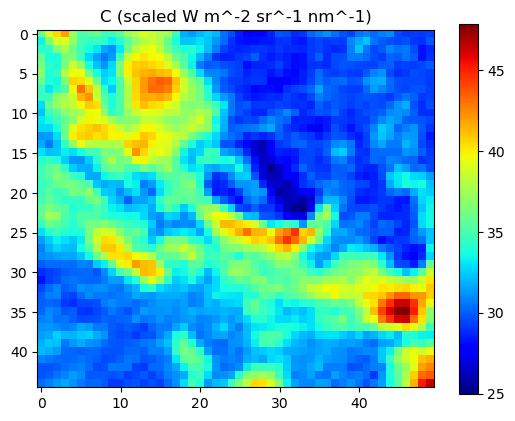

In [ ]:
plt.imshow(out_C, cmap="jet"); plt.colorbar(); plt.title("C (scaled W m^-2 sr^-1 nm^-1)")

CH4(ppm) stats on valid pixels: 6.1303835 6.511986 6.973219


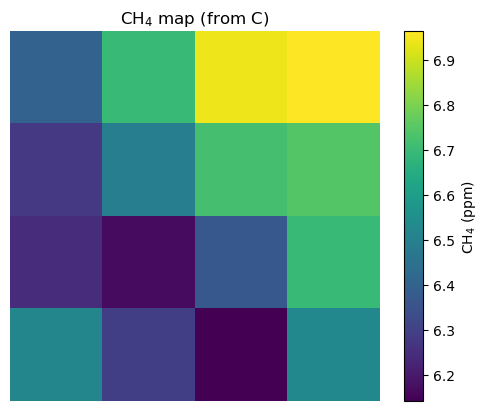

In [ ]:
def c_to_ch4_ppm(C):
    return 0.000556 * (C**2) + 0.1519 * C + 1.4475

valid = np.isfinite(out_C)
if 'out_QA' in globals():
    valid &= (out_QA == 0)

CH4_ppm = np.full_like(out_C, np.nan, dtype=np.float32)
CH4_ppm[valid] = c_to_ch4_ppm(out_C[valid])

print("CH4(ppm) stats on valid pixels:",
      np.nanmin(CH4_ppm), np.nanmean(CH4_ppm), np.nanmax(CH4_ppm))

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(CH4_ppm, vmin=np.nanpercentile(CH4_ppm, 2), vmax=np.nanpercentile(CH4_ppm, 98))
plt.colorbar(label="CH$_4$ (ppm)")
plt.title("CH$_4$ map (from C)")
plt.axis("off")
plt.show()


In [ ]:
H, W, C = img_slice.shape
out_A  = np.full((H, W), np.nan, dtype=np.float32)
out_C  = np.full((H, W), np.nan, dtype=np.float32)
out_QA = np.zeros((H, W), dtype=np.uint8)

df_param = df_param.copy()
df_param["absdiff"] = (df_param["CenterWavelengthNanometer"] - anchor_target).abs()
anchor_row = df_param.loc[df_param["absdiff"].idxmin()]

ANCHOR_CENTER = float(anchor_row["CenterWavelengthNanometer"])
ANCHOR_FWHM   = float(anchor_row["FullWidthAtHalfMaximumNanometer"])

CH4_BANDS = ch4_df[["CenterWavelengthNanometer","FullWidthAtHalfMaximumNanometer"]].to_numpy()

Lb_list = []
for center_nm, fwhm_nm in CH4_BANDS:
    Lb_list.append(
        convolve_band(wave_nm, rad_a10, float(center_nm), float(fwhm_nm))
    )
Lb_list = np.array(Lb_list, dtype=float)
N_CH4 = len(CH4_BANDS)  

for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img_slice, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        pix_wave = df["Wavelength"].to_numpy(dtype=float)
        pix_rad  = df["Radiance"].to_numpy(dtype=float)  

        idx_anchor  = int(np.abs(pix_wave - ANCHOR_CENTER).argmin())
        Lav_anchor  = float(pix_rad[idx_anchor])

        denom = (L10_anchor - L_path)
        if not np.isfinite(Lav_anchor) or denom <= 0:
            out_QA[y, x] = 1
            continue
        A = (Lav_anchor - L_path) / denom * 0.10
        if not np.isfinite(A) or A <= 0:
            out_QA[y, x] = 1
            continue

        chi = 0.10 / A

        sum_res = 0.0
        for j, (center_nm, fwhm_nm) in enumerate(CH4_BANDS):
            idx  = int(np.abs(pix_wave - center_nm).argmin())
            Lav  = float(pix_rad[idx])
            Lb   = float(Lb_list[j])
            Lres = Lb - chi * Lav
            sum_res += Lres

        C_scaled = (sum_res / (N_CH4 * A)) * 100.0

        out_A[y, x] = A
        out_C[y, x] = C_scaled

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


CH4(ppm) stats on valid pixels: -2.639651 12.235946 67.62072


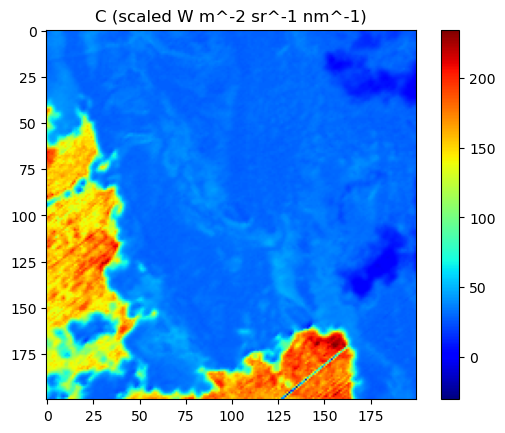

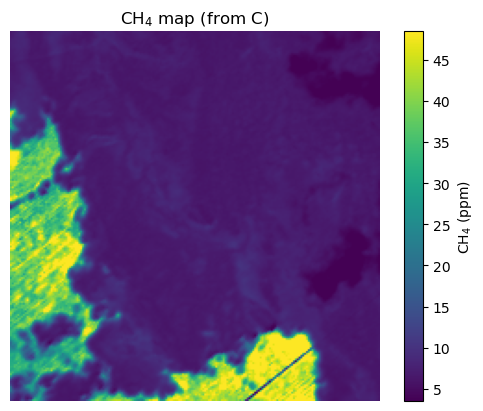

In [ ]:
plt.imshow(out_C, cmap="jet"); plt.colorbar(); plt.title("C (scaled W m^-2 sr^-1 nm^-1)")
def c_to_ch4_ppm(C):
    return 0.000556 * (C**2) + 0.1519 * C + 1.4475

valid = np.isfinite(out_C)
if 'out_QA' in globals():
    valid &= (out_QA == 0)

CH4_ppm = np.full_like(out_C, np.nan, dtype=np.float32)
CH4_ppm[valid] = c_to_ch4_ppm(out_C[valid])

print("CH4(ppm) stats on valid pixels:",
      np.nanmin(CH4_ppm), np.nanmean(CH4_ppm), np.nanmax(CH4_ppm))

import matplotlib.pyplot as plt
plt.figure()
plt.imshow(CH4_ppm, vmin=np.nanpercentile(CH4_ppm, 2), vmax=np.nanpercentile(CH4_ppm, 98))
plt.colorbar(label="CH$_4$ (ppm)")
plt.title("CH$_4$ map (from C)")
plt.axis("off")
plt.show()


In [ ]:
H, W, C = ims.shape
out_A  = np.full((H, W), np.nan, dtype=np.float32)
out_C  = np.full((H, W), np.nan, dtype=np.float32)
out_QA = np.zeros((H, W), dtype=np.uint8)

df_param = df_param.copy()
df_param["absdiff"] = (df_param["CenterWavelengthNanometer"] - anchor_target).abs()
anchor_row = df_param.loc[df_param["absdiff"].idxmin()]

ANCHOR_CENTER = float(anchor_row["CenterWavelengthNanometer"])
ANCHOR_FWHM   = float(anchor_row["FullWidthAtHalfMaximumNanometer"])

CH4_BANDS = ch4_df[["CenterWavelengthNanometer","FullWidthAtHalfMaximumNanometer"]].to_numpy()

Lb_list = []
for center_nm, fwhm_nm in CH4_BANDS:
    Lb_list.append(
        convolve_band(wave_nm, rad_a10, float(center_nm), float(fwhm_nm))
    )
Lb_list = np.array(Lb_list, dtype=float)
N_CH4 = len(CH4_BANDS)  

for y in range(H):
    print(y)
    for x in range(W):
        data_rad = get_radiance(img, param, y, x)
        df = pd.DataFrame(data_rad, columns=["Wavelength", "Radiance"])

        pix_wave = df["Wavelength"].to_numpy(dtype=float)
        pix_rad  = df["Radiance"].to_numpy(dtype=float)  

        idx_anchor  = int(np.abs(pix_wave - ANCHOR_CENTER).argmin())
        Lav_anchor  = float(pix_rad[idx_anchor])

        denom = (L10_anchor - L_path)
        if not np.isfinite(Lav_anchor) or denom <= 0:
            out_QA[y, x] = 1
            continue
        A = (Lav_anchor - L_path) / denom * 0.10
        if not np.isfinite(A) or A <= 0:
            out_QA[y, x] = 1
            continue

        chi = 0.10 / A

        sum_res = 0.0
        for j, (center_nm, fwhm_nm) in enumerate(CH4_BANDS):
            idx  = int(np.abs(pix_wave - center_nm).argmin())
            Lav  = float(pix_rad[idx])
            Lb   = float(Lb_list[j])
            Lres = Lb - chi * Lav
            sum_res += Lres

        C_scaled = (sum_res / (N_CH4 * A)) * 100.0

        out_A[y, x] = A
        out_C[y, x] = C_scaled

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

CH4(ppm) stats on valid pixels: -8.927323 10.109339 108.90672


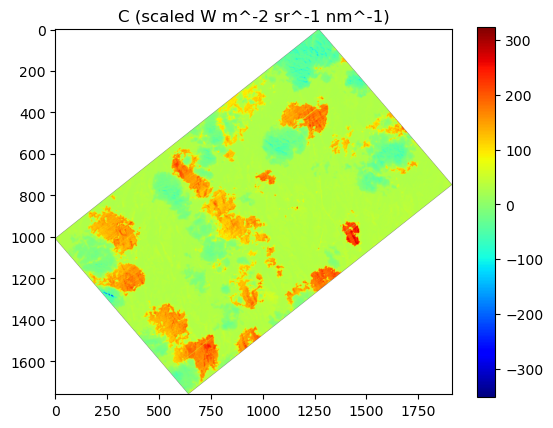

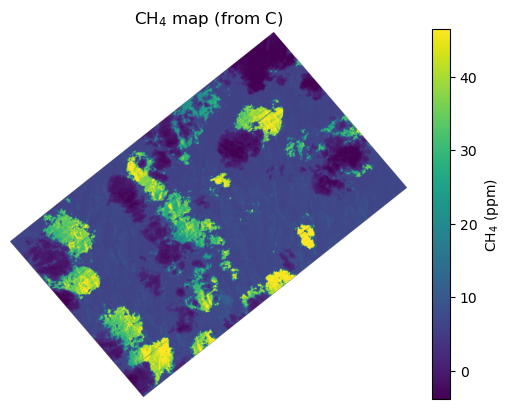

In [ ]:
plt.imshow(out_C, cmap="jet"); plt.colorbar(); plt.title("C (scaled W m^-2 sr^-1 nm^-1)")
def c_to_ch4_ppm(C):
    return 0.000556 * (C**2) + 0.1519 * C + 1.4475

valid = np.isfinite(out_C)
if 'out_QA' in globals():
    valid &= (out_QA == 0)

CH4_ppm = np.full_like(out_C, np.nan, dtype=np.float32)
CH4_ppm[valid] = c_to_ch4_ppm(out_C[valid])

print("CH4(ppm) stats on valid pixels:",
      np.nanmin(CH4_ppm), np.nanmean(CH4_ppm), np.nanmax(CH4_ppm))

plt.figure()
plt.imshow(CH4_ppm, vmin=np.nanpercentile(CH4_ppm, 2), vmax=np.nanpercentile(CH4_ppm, 98))
plt.colorbar(label="CH$_4$ (ppm)")
plt.title("CH$_4$ map (from C)")
plt.axis("off")
plt.show()


In [ ]:
# === 追加: bg_surref_由来のC値/CH4(ppm)を計算し、mod由来と比較 ===
import pandas as pd
import numpy as np

# 1) 入力パス（ユーザー指定）
surref_a0_path  = r"D:\methanewide\bgw\normalized\bg_surref_0.00_scan.csv"
surref_a10_path = r"D:\methanewide\bgw\normalized\bg_surref_0.10_scan.csv"

# 2) CSVの列名を自動判定して読み込み（先頭2列: 波長[nm], 値 を想定）
def load_two_col_csv(path):
    df = pd.read_csv(path)
    # 波長候補列
    wl_candidates = [c for c in df.columns if 'wave' in c.lower() or 'lambda' in c.lower() or 'nm' in c.lower()]
    if len(wl_candidates) == 0:
        wl_col = df.columns[0]
    else:
        wl_col = wl_candidates[0]
    # 値列
    val_cols = [c for c in df.columns if c != wl_col]
    if len(val_cols) == 0:
        raise ValueError(f"値列が見つかりません: {path}")
    val_col = val_cols[0]
    out = df[[wl_col, val_col]].copy()
    out.columns = ["wave_nm", "val"]  # 正規化
    return out

sur_a0 = load_two_col_csv(surref_a0_path)
sur_a10 = load_two_col_csv(surref_a10_path)

# 3) 波長の共通化（補間）。既存ノートブックの wave_nm に合わせる。
#    もし既に wave_nm, rad_a0/rad_a10 が定義済みなら、それに合わせる。
#    未定義なら surref 側の波長軸を採用。
if 'wave_nm' in globals():
    base_wave = np.asarray(wave_nm, dtype=float)
else:
    base_wave = np.asarray(sur_a0["wave_nm"].values, dtype=float)

# surref値を base_wave に線形補間（外挿は端値保持）
def interp_to(x_old, y_old, x_new):
    return np.interp(x_new, x_old, y_old, left=y_old[0], right=y_old[-1])

val_a0 = interp_to(sur_a0["wave_nm"].values, sur_a0["val"].values,  base_wave)
val_a10 = interp_to(sur_a10["wave_nm"].values, sur_a10["val"].values, base_wave)

# 4) 既存ユーティリティの存在チェック
if 'convolve_band' not in globals():
    raise RuntimeError("convolve_band が見つかりません。既存セル（RSR畳み込みの関数定義）を先に実行してください。")
if 'CH4_BANDS' not in globals():
    raise RuntimeError("CH4_BANDS が見つかりません。CH4帯域定義（中心波長・FWHM の配列）を先に用意してください。")
if 'c_to_ch4_local' not in globals():
    # JSON係数未ロードの場合は、ノートブック内のローカル回帰 or 既定係数関数を使う
    if 'c_to_ch4_ppm' in globals():
        c_to_ch4_local = c_to_ch4_ppm
    else:
        # フォールバック（Roberts+2010近似）
        def c_to_ch4_local(C):
            return 0.000556*(C**2) + 0.1519*C + 1.4475

# 5) アンカー帯域（例: W1416）を既存変数から取得。無ければ 1416 nm 近傍を自動選択。
if 'ANCHOR_CENTER' in globals() and 'ANCHOR_FWHM' in globals():
    anchor_center = float(ANCHOR_CENTER)
    anchor_fwhm   = float(ANCHOR_FWHM)
else:
    # 1416 nm に最も近い帯域をアンカーとする
    target_nm = 1416.0
    centers = np.array([float(c) for c, _ in CH4_BANDS])
    idx = int(np.abs(centers - target_nm).argmin())
    anchor_center = float(centers[idx])
    # FWHM はCH4_BANDSからは取れない場合があるので、代表値を設定（例: 10 nm）
    anchor_fwhm = 10.0

# 6) C値計算（surref版）。既存実装の式に極力合わせる。
#    - Lb_list: a10（A=0.10）スペクトルをRSR畳み込み
#    - Lav   : a0（A=0.00）スペクトルの「中心波長での値」（既存の pix_rad[idx] 相当）
#    - A     : アンカー帯域から推定（反射率ベースなので L_path=0 と仮定→簡略式）
def compute_C_from_surref(wave_nm, a0_vals, a10_vals):
    # Lb_list（各CH4帯域の“バンド内観測値”）
    Lb_list = []
    for center_nm, fwhm_nm in CH4_BANDS:
        Lb_list.append(convolve_band(wave_nm, a10_vals, float(center_nm), float(fwhm_nm)))
    Lb_list = np.asarray(Lb_list, dtype=float)

    # Lav：各帯域の中心「近傍」の a0 値（既存コードの idx→pix_rad[idx] に合わせる）
    Lav_list = []
    for center_nm, _ in CH4_BANDS:
        idx = int(np.abs(wave_nm - float(center_nm)).argmin())
        Lav_list.append(float(a0_vals[idx]))
    Lav_list = np.asarray(Lav_list, dtype=float)

    # アンカー帯域の値（簡略: 反射率→路程項 L_path を 0 と置く）
    L10_anchor = convolve_band(wave_nm, a10_vals, anchor_center, anchor_fwhm)
    Lav_anchor = convolve_band(wave_nm, a0_vals,  anchor_center, anchor_fwhm)
    # A の簡略推定（反射率前提のため 0.10 の比を取る）
    # 元式: A = (L_av_anchor - L_path) / (L10_anchor - L_path) * 0.10
    # ここでは L_path ≈ 0 として、A ≈ (Lav_anchor / L10_anchor) * 0.10
    A = (Lav_anchor / L10_anchor) * 0.10 if L10_anchor != 0 else np.nan
    # χ = A(LUTb)/A(estimated)
    chi = 0.10 / A if (A is not None and np.isfinite(A) and A != 0) else np.nan

    # 残差合計 → C（スケールは既存と同じ形に合わせる）
    N_CH4 = len(CH4_BANDS)
    Lres = Lb_list - chi * Lav_list
    sum_res = float(np.sum(Lres))
    C_scaled = (sum_res / (N_CH4 * A)) * 100.0
    return C_scaled, A, L10_anchor, Lav_anchor

# 7) surref から C と CH4(ppm)
C_surref, A_sur, L10_anc, Lav_anc = compute_C_from_surref(base_wave, val_a0, val_a10)
CH4_surref_ppm = float(c_to_ch4_local(C_surref))

# 8) 既存の mod 由来（rad_a0/rad_a10）でも単一値Cを計算（参照用）
def compute_C_from_pair(wave_nm, a0_vals, a10_vals):
    Lb_list = []
    for center_nm, fwhm_nm in CH4_BANDS:
        Lb_list.append(convolve_band(wave_nm, a10_vals, float(center_nm), float(fwhm_nm)))
    Lb_list = np.asarray(Lb_list, dtype=float)

    Lav_list = []
    for center_nm, _ in CH4_BANDS:
        idx = int(np.abs(wave_nm - float(center_nm)).argmin())
        Lav_list.append(float(a0_vals[idx]))
    Lav_list = np.asarray(Lav_list, dtype=float)

    L10_anchor = convolve_band(wave_nm, a10_vals, anchor_center, anchor_fwhm)
    Lav_anchor = convolve_band(wave_nm, a0_vals,  anchor_center, anchor_fwhm)
    A = (Lav_anchor / L10_anchor) * 0.10 if L10_anchor != 0 else np.nan
    chi = 0.10 / A if (A is not None and np.isfinite(A) and A != 0) else np.nan

    N_CH4 = len(CH4_BANDS)
    Lres = Lb_list - chi * Lav_list
    sum_res = float(np.sum(Lres))
    C_scaled = (sum_res / (N_CH4 * A)) * 100.0
    return C_scaled

C_mod_single = None
CH4_mod_single = None
if 'wave_nm' in globals() and 'rad_a0' in globals() and 'rad_a10' in globals():
    C_mod_single = compute_C_from_pair(np.asarray(wave_nm), np.asarray(rad_a0), np.asarray(rad_a10))
    CH4_mod_single = float(c_to_ch4_local(C_mod_single))

# 9) 結果を表示
rows = []
rows.append({
    "source": "surref (0.00/0.10)",
    "C_value": C_surref,
    "CH4_ppm": CH4_surref_ppm,
    "A_est": A_sur
})
if C_mod_single is not None:
    rows.append({
        "source": "mod (0.00/0.10)",
        "C_value": C_mod_single,
        "CH4_ppm": CH4_mod_single,
        "A_est": np.nan
    })
df_cmp = pd.DataFrame(rows)

# 差分列（modがあれば比較）
if C_mod_single is not None:
    df_cmp["ΔC (surref-mod)"]   = df_cmp.loc[0, "C_value"] - df_cmp.loc[1, "C_value"]
    df_cmp["Δppm (surref-mod)"] = df_cmp.loc[0, "CH4_ppm"] - df_cmp.loc[1, "CH4_ppm"]

print(df_cmp.round(6))


RuntimeError: convolve_band が見つかりません。既存セル（RSR畳み込みの関数定義）を先に実行してください。